<a href="https://colab.research.google.com/github/MithunSrinivas28/NN_using-_Numpy/blob/main/NN_using_numpy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
from google.colab import userdata
import os
import json

username = userdata.get('KAGGLE_USERNAME')
key = userdata.get('KAGGLE_KEY')

kaggle_credentials = {
    "username": username,
    "key": key
}

os.makedirs('/root/.kaggle', exist_ok=True)

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)

os.chmod('/root/.kaggle/kaggle.json', 600)

print("Kaggle configured successfully")

Kaggle API configured successfully


In [1]:
import pandas as pd
import numpy as np

import numpy as np
import pandas as pd

data = pd.read_csv("train.csv")
from matplotlib import pyplot as plt
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [2]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data)

data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]
X_dev = X_dev / 255.

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255.
_,m_train = X_train.shape

In [3]:
Y_train

array([0, 4, 7, ..., 8, 7, 6])

In [4]:
def init_params():
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z))
    return A

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def ReLU_deriv(Z):
    return Z > 0

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

In [5]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions, Y))
    return W1, b1, W2, b2

In [6]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.10, 500)

Iteration:  0
[8 9 1 ... 2 1 9] [0 4 7 ... 8 7 6]
0.08636585365853658
Iteration:  10
[0 3 5 ... 2 5 3] [0 4 7 ... 8 7 6]
0.2876341463414634
Iteration:  20
[0 3 5 ... 7 4 6] [0 4 7 ... 8 7 6]
0.3968048780487805
Iteration:  30
[0 3 7 ... 7 5 6] [0 4 7 ... 8 7 6]
0.47953658536585364
Iteration:  40
[0 4 7 ... 7 7 6] [0 4 7 ... 8 7 6]
0.541609756097561
Iteration:  50
[0 4 7 ... 7 7 6] [0 4 7 ... 8 7 6]
0.585390243902439
Iteration:  60
[0 4 7 ... 7 7 6] [0 4 7 ... 8 7 6]
0.6184634146341463
Iteration:  70
[0 4 7 ... 7 9 6] [0 4 7 ... 8 7 6]
0.6431951219512195
Iteration:  80
[0 4 7 ... 9 9 6] [0 4 7 ... 8 7 6]
0.6662682926829269
Iteration:  90
[0 4 7 ... 9 9 6] [0 4 7 ... 8 7 6]
0.6839756097560976
Iteration:  100
[0 4 7 ... 9 9 6] [0 4 7 ... 8 7 6]
0.6992195121951219
Iteration:  110
[0 4 7 ... 9 9 6] [0 4 7 ... 8 7 6]
0.7115609756097561
Iteration:  120
[0 4 7 ... 9 9 6] [0 4 7 ... 8 7 6]
0.7244146341463414
Iteration:  130
[0 4 7 ... 9 9 6] [0 4 7 ... 8 7 6]
0.7343414634146341
Iteration:  140
[

In [9]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)

    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [0]
Label:  0


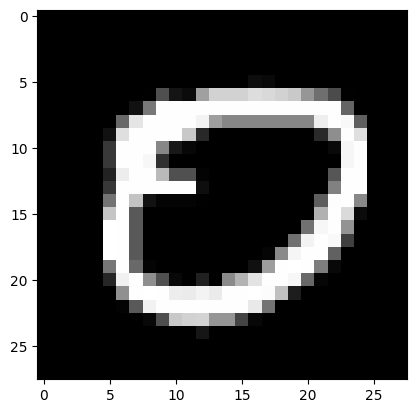

Prediction:  [9]
Label:  4


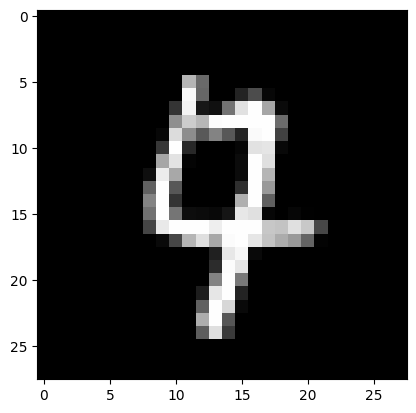

Prediction:  [7]
Label:  7


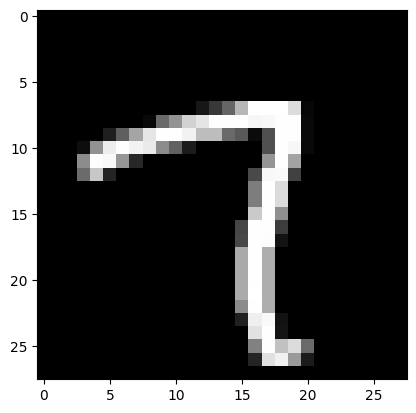

Prediction:  [2]
Label:  2


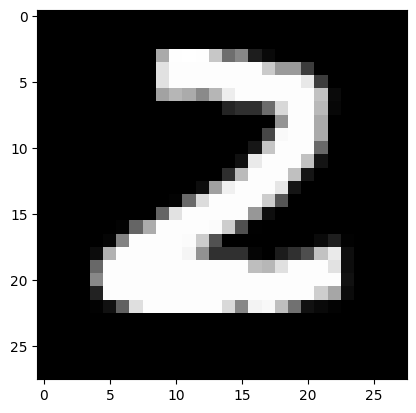

In [10]:
test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)

In [11]:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
get_accuracy(dev_predictions, Y_dev)

[1 1 8 3 1 7 3 8 7 9 4 7 1 7 5 1 6 1 6 2 6 0 0 3 0 5 2 2 3 4 0 2 9 1 3 3 0
 7 8 3 7 8 5 3 0 7 9 7 6 3 6 5 3 0 2 1 4 4 6 2 1 1 6 0 1 2 5 3 3 3 4 7 9 2
 7 8 2 7 9 8 6 3 5 5 7 4 7 8 2 0 1 3 7 3 5 1 7 9 3 2 2 2 7 5 7 9 3 8 9 0 0
 9 9 2 3 2 4 1 6 0 2 3 8 7 3 1 8 7 0 4 2 4 4 5 4 1 4 1 7 3 3 9 4 4 1 6 5 3
 5 9 5 6 7 4 4 0 5 6 9 6 6 6 6 4 2 3 1 4 4 9 4 6 9 5 3 1 7 5 5 3 8 5 0 1 9
 0 9 6 4 0 9 2 8 8 2 7 1 9 6 2 7 8 9 7 3 6 3 9 0 1 1 3 9 9 7 4 4 7 2 6 3 4
 7 7 6 6 1 9 9 3 1 1 6 7 0 3 9 4 4 5 1 8 1 3 3 0 0 9 2 1 5 8 1 1 1 1 2 0 1
 2 8 2 7 2 6 4 7 4 9 3 2 8 8 1 9 6 5 9 9 9 9 7 9 5 4 8 5 5 2 2 7 2 1 7 9 4
 2 6 0 4 1 4 4 1 3 3 6 7 1 4 8 2 8 7 3 0 8 8 0 6 3 7 7 4 5 7 8 9 9 6 1 5 1
 0 5 6 9 8 1 2 0 1 1 3 1 1 0 3 2 9 3 9 7 6 4 7 3 8 4 4 3 8 0 1 1 9 1 4 3 8
 6 9 0 4 1 4 5 0 3 9 0 6 5 8 3 1 2 6 1 3 1 3 6 8 1 7 1 6 8 6 8 0 5 7 9 4 3
 2 2 2 5 5 7 9 9 3 4 5 8 2 2 7 3 4 9 1 1 7 0 0 4 2 4 1 6 6 9 6 5 6 3 9 0 6
 7 8 7 4 4 7 6 7 6 1 1 4 4 5 7 7 6 8 6 1 3 3 3 6 6 1 2 5 7 6 4 7 3 5 5 8 3
 8 7 2 4 1 3 6 6 0 4 7 3 

np.float64(0.81)